 # Imports

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import joblib

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# Load Dataset

In [2]:
df = pd.read_csv(
    "../datasets/processed/D6_kmeans_ready.csv"
)

print("Dataset Loaded Successfully")
print("Shape:", df.shape)


Dataset Loaded Successfully
Shape: (119398, 144)


# Dataset Overview

In [15]:
df.head()

,latitude,longitude,temperature_celsius,wind_kph,wind_degree,pressure_mb,precip_mm,humidity,cloud,feels_like_celsius,visibility_km,uv_index,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination,year,month,day,hour,weekday,day_length_minutes,temperature_gap,pm_difference,pollution_intensity,wind_humidity_interaction,humidity_cloud_interaction,heatwave_index,region_1,region_2,region_3,region_4,region_5,region_6,region_7,region_8,region_9,region_10,region_11,region_12,region_13,region_14,region_15,region_16,region_17,region_18,region_19,region_20,region_21,region_22,region_23,region_24,region_25,region_26,region_27,region_28,region_29,region_30,region_31,region_32,timezone_1,timezone_2,condition_text_1,condition_text_2,condition_text_3,condition_text_4,condition_text_5,condition_text_6,condition_text_7,condition_text_8,condition_text_9,condition_text_10,condition_text_11,condition_text_12,condition_text_13,condition_text_14,condition_text_15,condition_text_16,condition_text_17,condition_text_18,condition_text_19,condition_text_20,condition_text_21,condition_text_22,condition_text_23,condition_text_24,condition_text_25,condition_text_26,condition_text_27,condition_text_28,condition_text_29,condition_text_30,condition_text_31,condition_text_32,condition_text_33,condition_text_34,condition_text_35,condition_text_36,condition_text_37,condition_text_38,condition_text_39,condition_text_40,condition_text_41,condition_text_42,condition_text_43,condition_text_44,condition_text_45,condition_text_46,condition_text_47,condition_text_48,condition_text_49,wind_direction_1,wind_direction_2,wind_direction_3,wind_direction_4,wind_direction_5,wind_direction_6,wind_direction_7,wind_direction_8,wind_direction_9,wind_direction_10,wind_direction_11,wind_direction_12,wind_direction_13,wind_direction_14,wind_direction_15,moon_phase_1,moon_phase_2,moon_phase_3,moon_phase_4,moon_phase_5,moon_phase_6,moon_phase_7,day_period_1,day_period_2,season_1,season_2,season_3,climate_cluster
0,24.57,77.72,27.5,20.5,281,1008,0.0,67,26,29.7,10.0,7,23.8,243.7,45.8,1.7,3.1,12.6,18.5,1,2,93,2023,8,29,10,1,762.0,2.2,5.9,274.8,1373.5,1742,192.5,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,True,False,False,False,False,0
1,23.33,77.80,27.5,15.5,287,1008,0.0,70,19,30.0,10.0,7,18.0,240.3,38.3,2.1,2.6,10.7,14.2,1,1,93,2023,8,29,10,1,760.0,2.5,3.5,265.2,1085.0,1330,192.5,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,True,False,False,False,False,0
2,22.07,78.93,26.3,18.4,317,1009,0.0,70,51,28.2,10.0,7,21.2,220.3,57.2,0.6,1.7,16.8,20.7,2,2,93,2023,8,29,10,1,758.0,1.9,3.9,257.8,1288.0,3570,184.1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,Fa

In [16]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 119398 entries, 0 to 119397
Columns: 145 entries, latitude to climate_cluster
dtypes: bool(110), float64(20), int32(1), int64(14)
memory usage: 44.0 MB


# Select Clustering Features

In [4]:
clustering_features = [
    "temperature_celsius",
    "humidity",
    "pressure_mb",
    "precip_mm",
    "cloud",
    "uv_index",
    "visibility_km",
    "air_quality_PM2.5",
    "air_quality_PM10",
    "air_quality_Carbon_Monoxide",
    "air_quality_Ozone",
    "air_quality_Nitrogen_dioxide",
    "air_quality_Sulphur_dioxide",
    "day_length_minutes",
    "temperature_gap"
]

X = df[clustering_features]

print(X.shape)



(119398, 15)


# Scale Features

In [5]:
cluster_scaler = RobustScaler()

X_scaled = cluster_scaler.fit_transform(X)

print(X_scaled.shape)



(119398, 15)


# Save Clustering Scaler


In [6]:

joblib.dump(
    cluster_scaler,
    "../models/clustering_scaler.pkl"
)

print("Clustering scaler saved")

Clustering scaler saved


# Elbow Method


In [7]:

inertia = []

k_values = range(2, 11)

for k in k_values:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertia.append(model.inertia_)


# Plot Elbow Curve

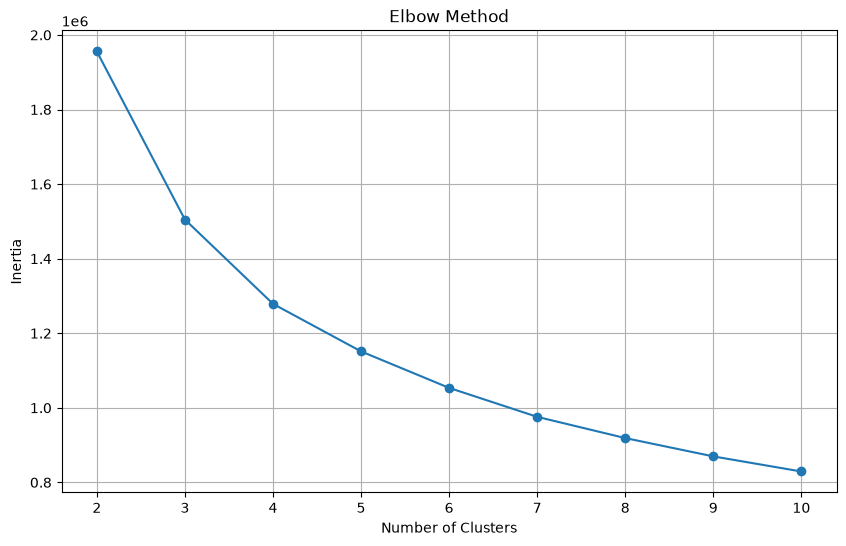

In [8]:


plt.figure(figsize=(10,6))

plt.plot(
    k_values,
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.grid()

plt.show()


# Silhouette Scores

In [9]:


silhouette_scores = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

    print(
        f"K={k} | Silhouette Score={score:.4f}"
    )

K=2 | Silhouette Score=0.5047
K=3 | Silhouette Score=0.5009
K=4 | Silhouette Score=0.3462
K=5 | Silhouette Score=0.3378
K=6 | Silhouette Score=0.2588
K=7 | Silhouette Score=0.2472
K=8 | Silhouette Score=0.2538
K=9 | Silhouette Score=0.2492
K=10 | Silhouette Score=0.2202


In [10]:
sample_size = min(20000, len(X_scaled))

score = silhouette_score(
    X_scaled,
    labels,
    sample_size=sample_size,
    random_state=42
)

 # Plot Silhouette Scores




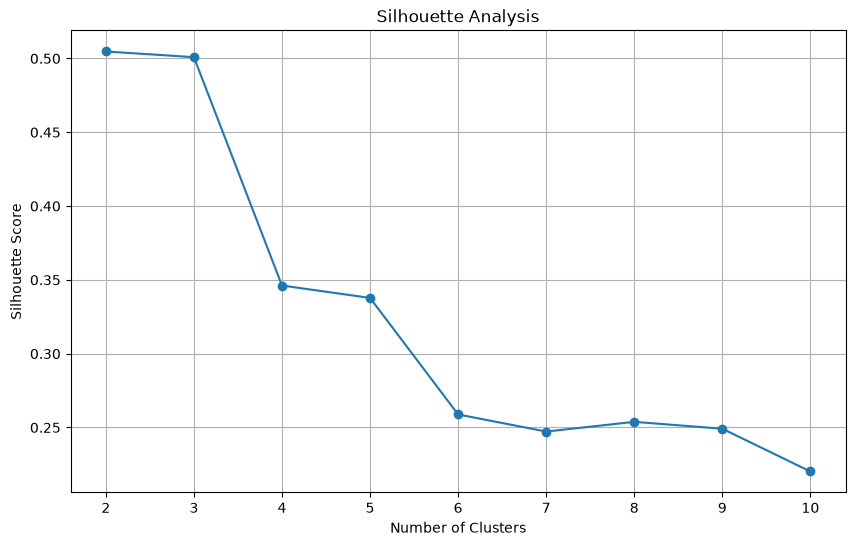

In [11]:

plt.figure(figsize=(10,6))

plt.plot(
    range(2,11),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

plt.grid()

plt.show()

 # Choose Best K 

In [12]:
optimal_k = 4

 # Train Final KMeans

In [13]:

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

df["climate_cluster"] = kmeans.fit_predict(
    X_scaled
)

print(
    df["climate_cluster"].value_counts()
)


climate_cluster
0    76403
1    22459
2    19162
3     1374
Name: count, dtype: int64


C:\Users\User\AppData\Local\Temp\ipykernel_19392\2877740220.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["climate_cluster"] = kmeans.fit_predict(


# Cluster Centers 

In [14]:


centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=clustering_features
)

centers


,temperature_celsius,humidity,pressure_mb,precip_mm,cloud,uv_index,visibility_km,air_quality_PM2.5,air_quality_PM10,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,day_length_minutes,temperature_gap
0,-0.061927,-0.093540,-0.127963,0.084442,0.362722,0.107458,-0.055535,-0.046072,-0.066569,-0.076144,0.200124,-0.047828,0.093002,0.079309,0.309552
1,0.082788,0.411462,-0.014471,0.148883,0.750239,0.074758,-6.823919,0.266850,0.276657,0.421414,0.031617,0.423374,0.694146,0.108129,0.694653
2,-0.529719,-0.328666,0.345170,0.009406,0.068881,0.008506,-0.025732,1.884829,1.848966,1.738586,-0.166059,1.327449,1.242115,-0.533558,0.051409
3,0.094456,0.055615,0.049733,0.067999,0.348472,0.048035,-4.468996,3.365174,3.694978,6.030911,-0.529945,5.816535,16.861300,-0.072712,0.507584


# Convert Centers Back To Original Scale 

In [17]:
centers_original = pd.DataFrame(
    cluster_scaler.inverse_transform(
        kmeans.cluster_centers_
    ),
    columns=clustering_features
)

centers_original

,temperature_celsius,humidity,pressure_mb,precip_mm,cloud,uv_index,visibility_km,air_quality_PM2.5,air_quality_PM10,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,day_length_minutes,temperature_gap
0,20.686010,59.164852,1012.232219,0.084442,22.508861,1.107458,9.944465,56.582480,69.122815,542.164640,48.145486,9.344753,4.002213,695.075783,0.588150
1,21.887137,79.869941,1012.913175,0.148883,38.009573,1.074758,3.176081,83.869344,102.518754,794.625460,40.697462,15.800218,7.248390,696.920255,1.319841
2,16.803329,49.524709,1015.071022,0.009406,10.755258,1.008506,9.974268,224.957110,255.504399,1462.958430,31.960194,28.186051,10.207421,655.852320,0.097678
3,21.983988,65.280204,1013.298399,0.067999,21.938865,1.048035,5.531004,354.043159,435.121325,3640.883988,15.876419,89.686536,94.551019,685.346434,0.964410


# Cluster Statistics 

In [18]:
cluster_summary = df.groupby(
    "climate_cluster"
)[clustering_features].mean()

cluster_summary

,temperature_celsius,humidity,pressure_mb,precip_mm,cloud,uv_index,visibility_km,air_quality_PM2.5,air_quality_PM10,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,day_length_minutes,temperature_gap
climate_cluster,,,,,,,,,,,,,,,
0,20.686029,59.165072,1012.232268,0.084441,22.508658,1.107457,9.944466,56.582825,69.123169,542.166018,48.145483,9.344963,4.002470,695.075429,0.588173
1,21.887137,79.869941,1012.913175,0.148883,38.009573,1.074758,3.176081,83.869344,102.518754,794.625460,40.697462,15.800218,7.248390,696.920255,1.319841
2,16.803048,49.523327,1015.070974,0.009407,10.755454,1.008506,9.974267,224.964518,255.512713,1463.000986,31.959362,28.186197,10.206722,655.851686,0.097558
3,21.983988,65.280204,1013.298399,0.067999,21.938865,1.048035,5.531004,354.043159,435.121325,3640.883988,15.876419,89.686536,94.551019,685.346434,0.964410


# Interpret Clusters 

In [19]:
# Look at:

# Highest precip_mm
# Highest humidity
# Highest cloud

# → Flood-Prone


# Highest PM2.5
# Highest PM10
# Highest CO

# → Pollution-Prone

# Moderate values everywhere

# → Moderate


# Create Cluster Mapping 

In [20]:

cluster_mapping = {
    0: "Moderate",
    1: "Flood-Prone",
    2: "Pollution-Prone",
    3: "Extreme-Pollution"

}

# Create Climate Profile Column 

In [21]:

df["climate_profile"] = (
    df["climate_cluster"]
    .map(cluster_mapping)
)

df[
    [
        "climate_cluster",
        "climate_profile"
    ]
].head()


C:\Users\User\AppData\Local\Temp\ipykernel_19392\813968590.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["climate_profile"] = (


,climate_cluster,climate_profile
0,0,Moderate
1,0,Moderate
2,0,Moderate
3,0,Moderate
4,0,Moderate


# Climate Profile Distribution 

In [22]:
print(
    df["climate_profile"]
    .value_counts()
)


climate_profile
Moderate             76403
Flood-Prone          22459
Pollution-Prone      19162
Extreme-Pollution     1374
Name: count, dtype: int64


# Create Climate Profile Column 

In [23]:


df["climate_profile"] = (
    df["climate_cluster"]
    .map(cluster_mapping)
)
df[
    [
        "climate_cluster",
        "climate_profile"
    ]
].head()


,climate_cluster,climate_profile
0,0,Moderate
1,0,Moderate
2,0,Moderate
3,0,Moderate
4,0,Moderate



# Climate Profile Distribution 

In [24]:

print(
    df["climate_profile"]
    .value_counts()
)

climate_profile
Moderate             76403
Flood-Prone          22459
Pollution-Prone      19162
Extreme-Pollution     1374
Name: count, dtype: int64


# Visualize Climate Profiles 

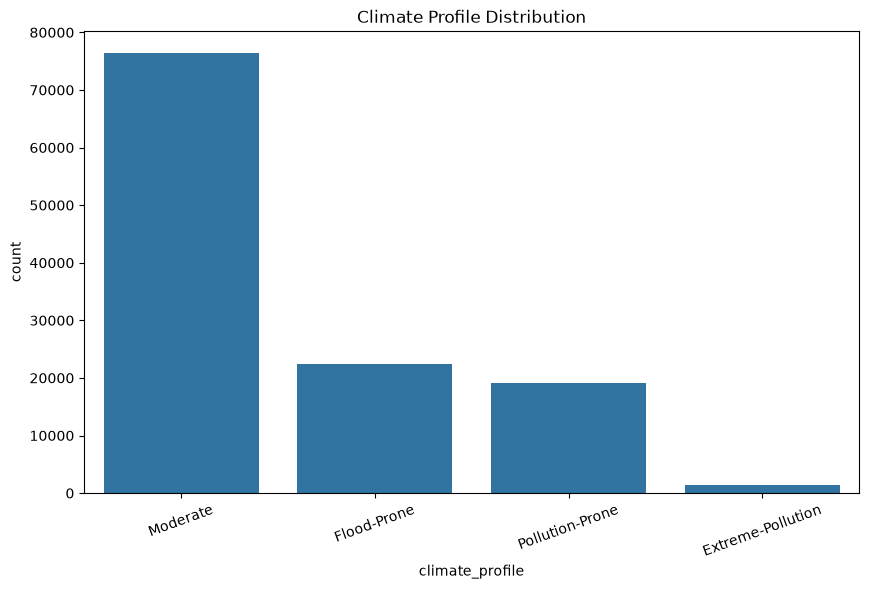

In [25]:
plt.figure(figsize=(10,6))

sns.countplot(
    x="climate_profile",
    data=df
)

plt.title(
    "Climate Profile Distribution"
)

plt.xticks(rotation=20)

plt.show()

# Save KMeans Model 

In [26]:


joblib.dump(
    kmeans,
    "../models/kmeans_climate_profile.pkl"
)

print("KMeans model saved")


KMeans model saved


# Save Dataset 


In [27]:

df.to_csv(
    "../datasets/processed/climate_profiles.csv",
    index=False
)

print(
    "dataset saved successfully"
)


dataset saved successfully


# Verification 

In [28]:
saved_df = pd.read_csv(
    "../datasets/processed/climate_profiles.csv"
)

print(saved_df.shape)

print(
    saved_df["climate_profile"]
    .value_counts()
)


(119398, 146)
climate_profile
Moderate             76403
Flood-Prone          22459
Pollution-Prone      19162
Extreme-Pollution     1374
Name: count, dtype: int64


# Climate Profile Discovery Report 

In [29]:
print("""

CLIMATE PROFILE DISCOVERY REPORT

Algorithm:
KMeans Clustering

Cluster Selection:
Elbow Method
Silhouette Score

Final K:
4

Climate Profiles:

1. Flood-Prone

2. Extreme-Pollution

3. Pollution-Prone

4. Moderate

Artifacts Saved:

kmeans_climate_profile.pkl

clustering_scaler.pkl

Dataset Output:

climate_profiles.csv

Completed Successfully

""")





CLIMATE PROFILE DISCOVERY REPORT

Algorithm:
KMeans Clustering

Cluster Selection:
Elbow Method
Silhouette Score

Final K:
4

Climate Profiles:

1. Flood-Prone

2. Extreme-Pollution

3. Pollution-Prone

4. Moderate

Artifacts Saved:

kmeans_climate_profile.pkl

clustering_scaler.pkl

Dataset Output:

climate_profiles.csv

Completed Successfully


